<a href="https://colab.research.google.com/github/olivia-m96/comp8535-MovieRecommendation/blob/main/comp8535.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

# Create a project folder in Google Drive
project_path = '/content/drive/MyDrive/COMP8535_Topic2'
os.makedirs(project_path, exist_ok=True)

# Download dataset into Drive folder (only if not already there)
if not os.path.exists(f'{project_path}/ml-100k'):
    !wget -q http://files.grouplens.org/datasets/movielens/ml-100k.zip -P {project_path}
    !unzip -q {project_path}/ml-100k.zip -d {project_path}
    print("Dataset downloaded to Google Drive!")
else:
    print("Dataset already in Google Drive, skipping download!")


os.chdir(project_path)

print(f"Current working directory changed to: {os.getcwd()}")

Dataset already in Google Drive, skipping download!
Current working directory changed to: /content/drive/MyDrive/COMP8535_Topic2


In [5]:
import pandas as pd
import numpy as np

# Load ratings data
# Columns: user_id, movie_id, rating, timestamp
ratings = pd.read_csv('ml-100k/u.data',
                      sep='\t',
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Load movie titles
movies = pd.read_csv('ml-100k/u.item',
                     sep='|',
                     encoding='latin-1',
                     usecols=[0, 1],
                     names=['movie_id', 'title'])

print("Ratings shape:", ratings.shape)
print("\nFirst few ratings:")
print(ratings.head())
print("\nFirst few movies:")
print(movies.head())

Ratings shape: (100000, 4)

First few ratings:
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596

First few movies:
   movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995)


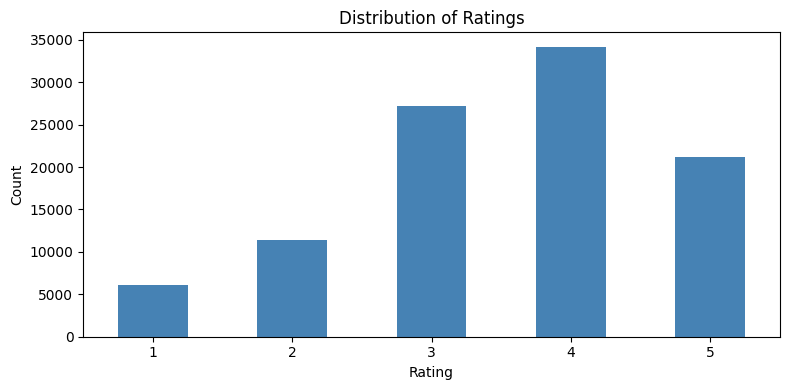

Rating counts:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt

# --- Plot 1: Rating distribution ---
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{project_path}/rating_distribution.png', dpi=150)
plt.show()
print("Rating counts:")
print(ratings['rating'].value_counts().sort_index())

In [7]:
# --- Sparsity of the rating matrix ---
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Number of users:  {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"Matrix sparsity: {sparsity:.2%}")

Number of users:  943
Number of movies: 1682
Number of ratings: 100000
Matrix sparsity: 93.70%


In [8]:
from scipy.sparse import csr_matrix

# Create user-movie matrix
# Rows = users, Columns = movies, Values = ratings
user_movie_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)  # fill missing ratings with 0

print("User-Movie matrix created!")
print(f"Matrix shape: {user_movie_matrix.shape}")
print(f"(943 users x 1682 movies = {943*1682} possible ratings)")
print(f"But only have {len(ratings)} actual ratings")
print(f"Sparsity: {1 - len(ratings)/(943*1682):.2%} empty")

User-Movie matrix created!
Matrix shape: (943, 1682)
(943 users x 1682 movies = 1586126 possible ratings)
But only have 100000 actual ratings
Sparsity: 93.70% empty


Apply SVD

In [9]:
from scipy.sparse.linalg import svds

# Convert to numpy matrix
R = user_movie_matrix.values  # shape: (943, 1682)

# Mean-centre the ratings (subtract each user's average rating)
# to remove user bias (some users always rate high/low)
user_ratings_mean = np.mean(R, axis=1)
R_demeaned = R - user_ratings_mean.reshape(-1, 1)

# Apply SVD
# k = number of latent factors (like hidden "taste dimensions")
k = 50  # will be tuned later
U, sigma, Vt = svds(R_demeaned, k=k)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

print("SVD applied")
print(f"U shape: {U.shape}       → users x latent factors")
print(f"Sigma shape: {sigma.shape}   → latent factors x latent factors")
print(f"Vt shape: {Vt.shape}    → latent factors x movies")

SVD applied
U shape: (943, 50)       → users x latent factors
Sigma shape: (50, 50)   → latent factors x latent factors
Vt shape: (50, 1682)    → latent factors x movies


In [13]:
# Reconstruct the full ratings matrix from SVD components
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

# Convert back to DataFrame with proper labels
preds_df = pd.DataFrame(
    all_user_predicted_ratings,
    columns=user_movie_matrix.columns,
    index=user_movie_matrix.index
)

print("Predictions reconstructed")
print(f"Predictions matrix shape: {preds_df.shape}")
print("\nSample predicted ratings (User 1, first 5 movies):")
print(preds_df.iloc[0, :5].round(2))

Predictions reconstructed
Predictions matrix shape: (943, 1682)

Sample predicted ratings (User 1, first 5 movies):
movie_id
1    6.49
2    2.96
3    1.63
4    3.02
5    1.66
Name: 1, dtype: float64


In [16]:
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
train_data, test_data = train_test_split(ratings, test_size=0.2, random_state=42)

# --- Rebuild with fix ---

# Build train matrix
train_matrix = train_data.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

train_matrix = train_matrix.reindex(
    columns=user_movie_matrix.columns,
    fill_value=0
)

R_train = train_matrix.values.astype(float)

# Fix: only compute mean over RATED items (non-zero)
user_ratings_mean_train = np.true_divide(
    R_train.sum(axis=1),
    (R_train != 0).sum(axis=1),
    where=(R_train != 0).sum(axis=1) != 0
)

# Subtract mean only from rated entries
R_train_demeaned = R_train.copy()
for i in range(R_train.shape[0]):
    mask = R_train[i] != 0
    R_train_demeaned[i, mask] -= user_ratings_mean_train[i]

# Apply SVD
U_train, sigma_train, Vt_train = svds(R_train_demeaned, k=50)
sigma_train = np.diag(sigma_train)

# Reconstruct
train_preds = np.dot(np.dot(U_train, sigma_train), Vt_train) + user_ratings_mean_train.reshape(-1, 1)

# Clip predictions to valid rating range 1-5
train_preds = np.clip(train_preds, 1, 5)

train_preds_df = pd.DataFrame(
    train_preds,
    columns=train_matrix.columns,
    index=train_matrix.index
)

# --- Evaluate ---
predictions = []
actuals = []

for _, row in test_data.iterrows():
    user = row['user_id']
    movie = row['movie_id']
    actual = row['rating']

    if user in train_preds_df.index and movie in train_preds_df.columns:
        predicted = train_preds_df.loc[user, movie]
        predictions.append(predicted)
        actuals.append(actual)

rmse = sqrt(mean_squared_error(actuals, predictions))
mae = np.mean(np.abs(np.array(actuals) - np.array(predictions)))

print(f"SVD Evaluation Results:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"Evaluated on {len(predictions)} test ratings")

SVD Evaluation Results:
RMSE: 1.0016
MAE:  0.7948
Evaluated on 20000 test ratings


NMF for Comparison

In [17]:
from sklearn.decomposition import NMF

# NMF requires non-negative values (use raw ratings (no demeaning))
# Build train matrix (same as before but no demeaning)
R_train_raw = train_matrix.values.astype(float)

# Apply NMF
nmf_model = NMF(n_components=50, random_state=42, max_iter=500)
U_nmf = nmf_model.fit_transform(R_train_raw)  # users x components
Vt_nmf = nmf_model.components_               # components x movies

# Reconstruct predictions
nmf_preds = np.dot(U_nmf, Vt_nmf)

# Clip to valid range 1-5
nmf_preds = np.clip(nmf_preds, 1, 5)

nmf_preds_df = pd.DataFrame(
    nmf_preds,
    columns=train_matrix.columns,
    index=train_matrix.index
)

# --- Evaluate NMF ---
predictions_nmf = []
actuals_nmf = []

for _, row in test_data.iterrows():
    user = row['user_id']
    movie = row['movie_id']
    actual = row['rating']

    if user in nmf_preds_df.index and movie in nmf_preds_df.columns:
        predicted = nmf_preds_df.loc[user, movie]
        predictions_nmf.append(predicted)
        actuals_nmf.append(actual)

rmse_nmf = sqrt(mean_squared_error(actuals_nmf, predictions_nmf))
mae_nmf = np.mean(np.abs(np.array(actuals_nmf) - np.array(predictions_nmf)))

print(f"NMF Evaluation Results:")
print(f"RMSE: {rmse_nmf:.4f}")
print(f"MAE:  {mae_nmf:.4f}")
print(f"Evaluated on {len(predictions_nmf)} test ratings")

NMF Evaluation Results:
RMSE: 2.4388
MAE:  2.1721
Evaluated on 20000 test ratings


Comparison Plot

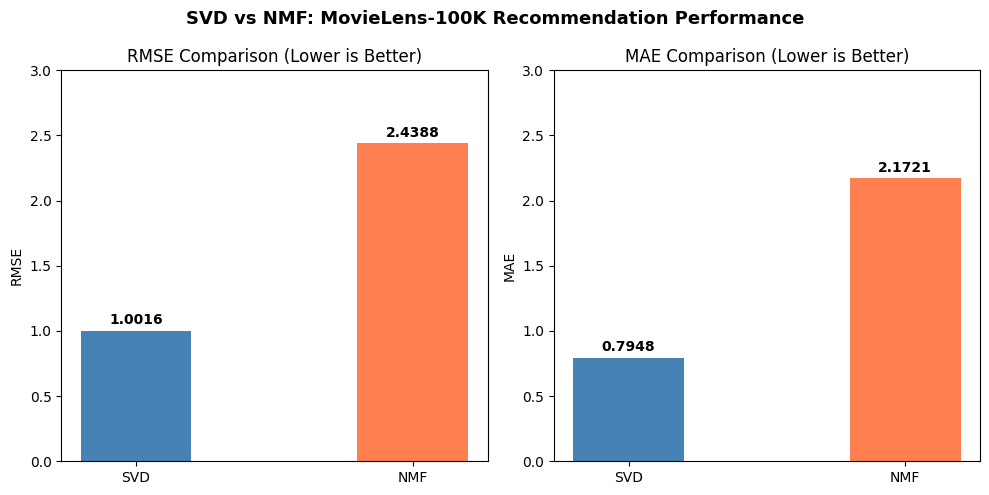


Comparison Summary:
Method     RMSE       MAE       
SVD        1.0016     0.7948    
NMF        2.4388     2.1721    

Winner: because SVD has lower RMSE and MAE


In [18]:
# --- Comparison Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Data
methods = ['SVD', 'NMF']
rmse_scores = [1.0016, rmse_nmf]
mae_scores = [0.7948, mae_nmf]

# RMSE plot
axes[0].bar(methods, rmse_scores, color=['steelblue', 'coral'], width=0.4)
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0, 3)
for i, v in enumerate(rmse_scores):
    axes[0].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')

# MAE plot
axes[1].bar(methods, mae_scores, color=['steelblue', 'coral'], width=0.4)
axes[1].set_title('MAE Comparison (Lower is Better)')
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0, 3)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('SVD vs NMF: MovieLens-100K Recommendation Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svd_vs_nmf_comparison.png', dpi=150)
plt.show()

print("\nComparison Summary:")
print(f"{'Method':<10} {'RMSE':<10} {'MAE':<10}")
print(f"{'SVD':<10} {1.0016:<10.4f} {0.7948:<10.4f}")
print(f"{'NMF':<10} {rmse_nmf:<10.4f} {mae_nmf:<10.4f}")
print(f"\nWinner: because SVD has lower RMSE and MAE")


Visualisation

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import random

# --- Step 1: Get movie latent factors from SVD ---
# Vt shape is (50, 1682) → transpose to (1682, 50)
# Each row = one movie represented in 50 latent dimensions
movie_factors = Vt_train.T  # shape: (1682, 50)

# --- Step 2: Randomly select 100 movies ---
random.seed(42)  # for reproducibility
sample_indices = random.sample(range(movie_factors.shape[0]), 100)

# Get their factors and titles
sample_factors = movie_factors[sample_indices]
sample_ids = user_movie_matrix.columns[sample_indices]
sample_titles = movies[movies['movie_id'].isin(sample_ids)]['title'].values

print(f"Selected {len(sample_indices)} movies")
print(f"Sample titles: {sample_titles[:5]}")

Selected 100 movies
Sample titles: ['Postino, Il (1994)' 'Madness of King George, The (1994)'
 'Professional, The (1994)' 'Stargate (1994)'
 'While You Were Sleeping (1995)']


 PCA applied!
Variance explained by 2 components: 31.50%


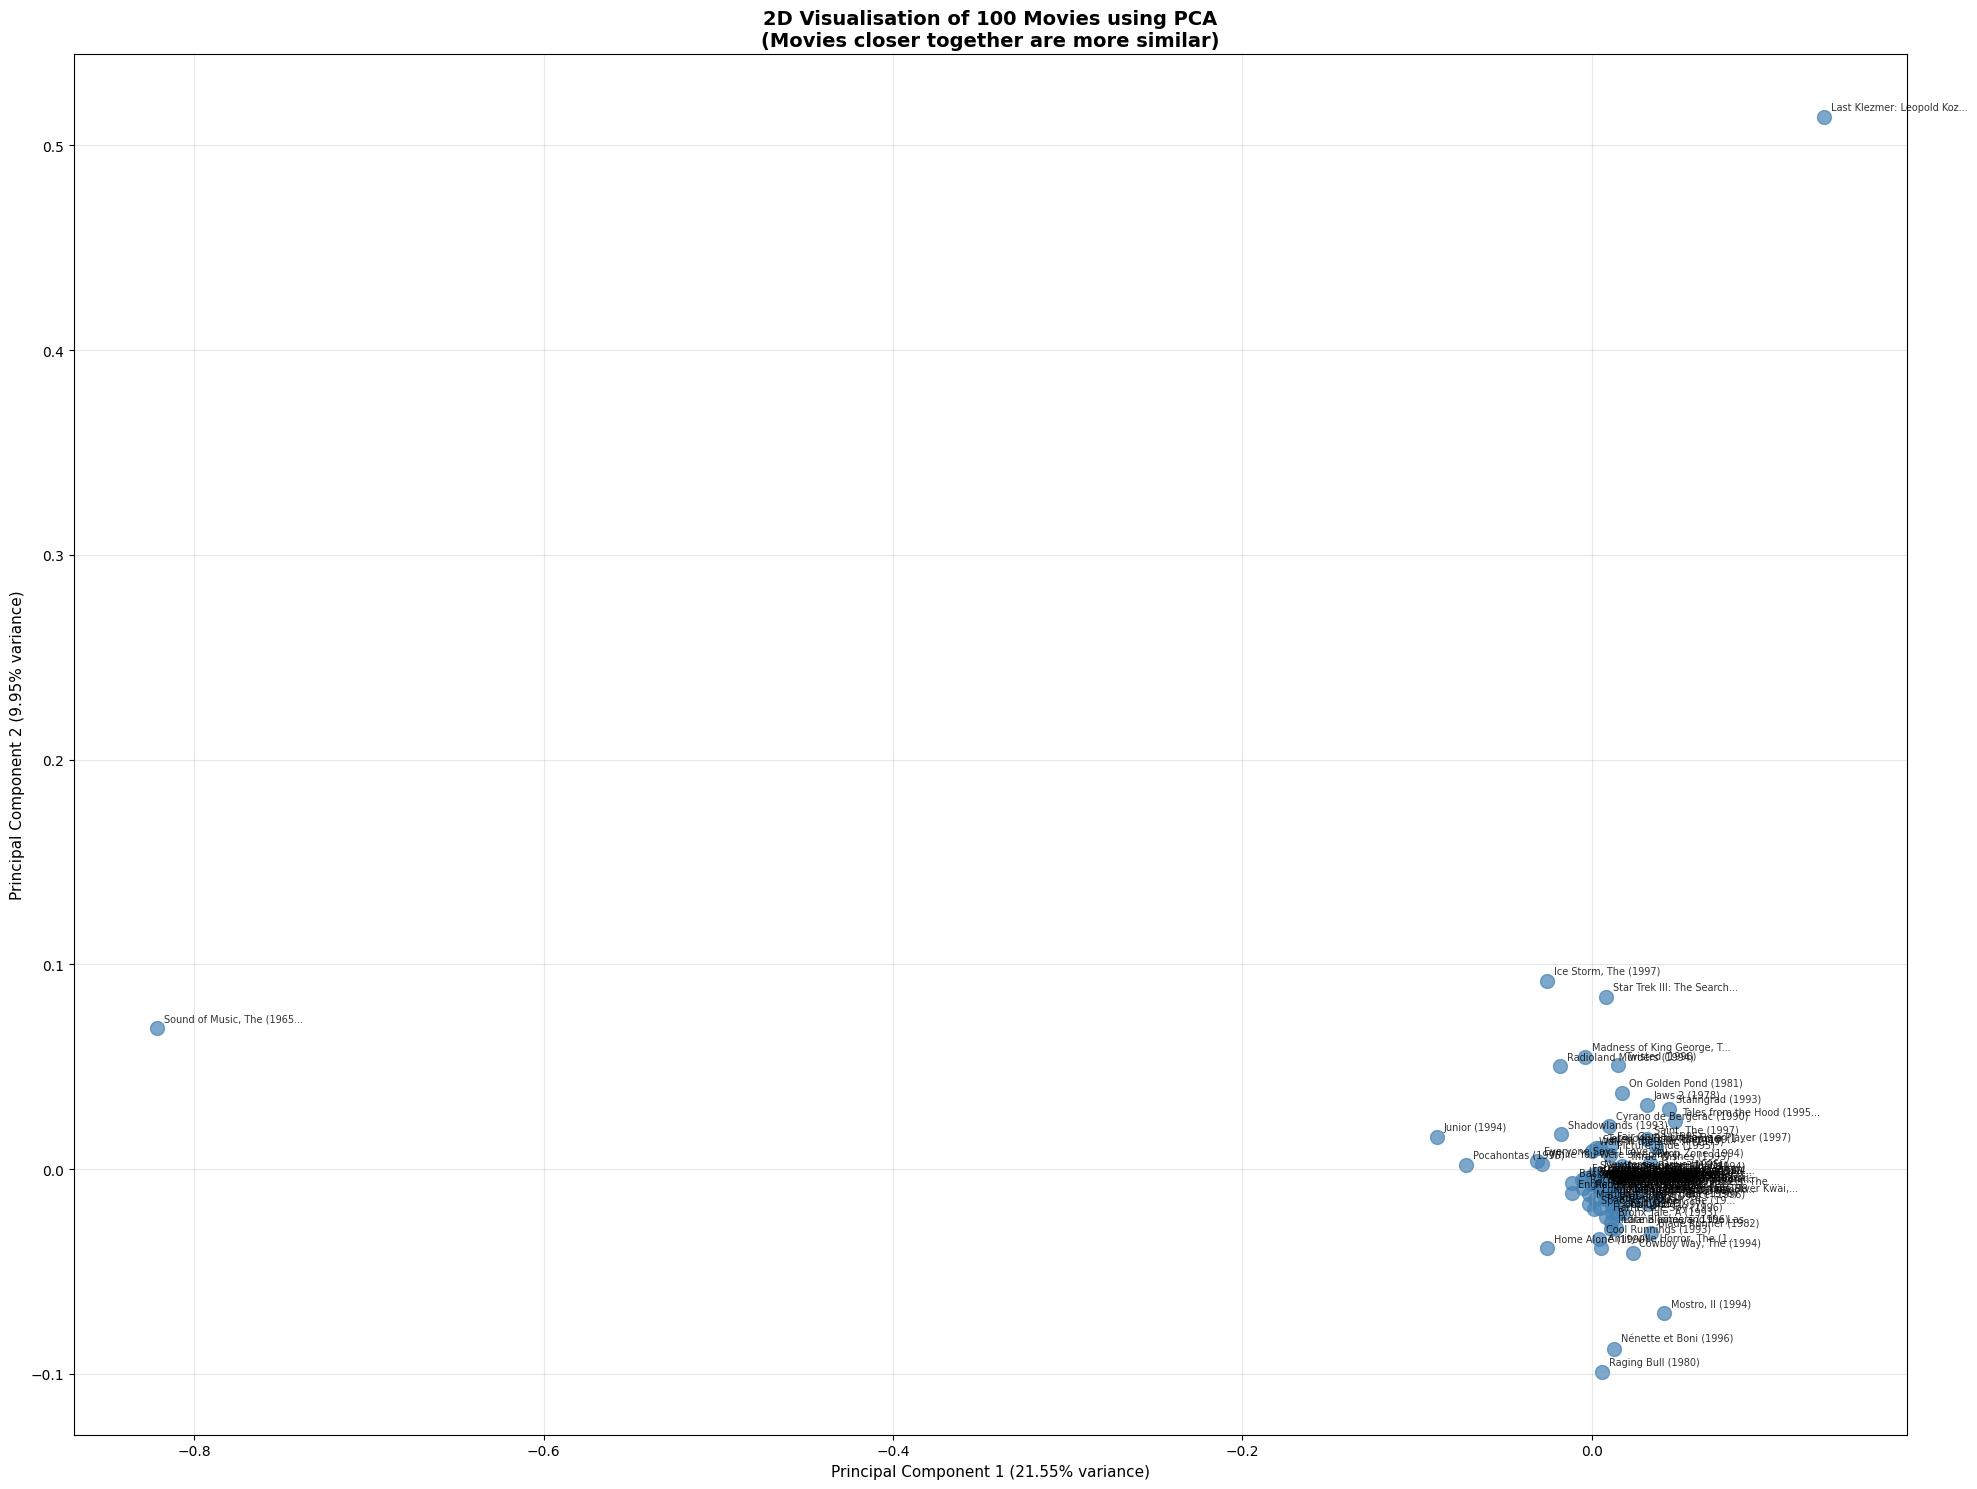

Plot saved!


In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Apply PCA to reduce 50 dimensions → 2 dimensions ---
pca = PCA(n_components=2, random_state=42)
movie_2d = pca.fit_transform(sample_factors)

print(f" PCA applied!")
print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 15))

ax.scatter(movie_2d[:, 0], movie_2d[:, 1],
           alpha=0.7, s=100, color='steelblue')

# Add movie title labels
for i, title in enumerate(sample_titles):
    # Shorten long titles for readability
    short_title = title[:25] + '...' if len(title) > 25 else title
    ax.annotate(short_title,
                (movie_2d[i, 0], movie_2d[i, 1]),
                fontsize=7,
                alpha=0.8,
                xytext=(5, 5),
                textcoords='offset points')

ax.set_title('2D Visualisation of 100 Movies using PCA\n(Movies closer together are more similar)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('movie_visualisation_pca.png', dpi=150)
plt.show()

print("Plot saved!")

In [21]:
# Load genre information
genres_df = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                         header=None)
genres_df.columns = ['movie_id', 'title', 'release_date', 'video_release',
                      'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                      'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
                      'Fantasy', 'FilmNoir', 'Horror', 'Musical', 'Mystery',
                      'Romance', 'SciFi', 'Thriller', 'War', 'Western']

# Get primary genre for each sampled movie
genre_columns = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy',
                 'Crime', 'Documentary', 'Drama', 'Fantasy', 'FilmNoir',
                 'Horror', 'Musical', 'Mystery', 'Romance', 'SciFi',
                 'Thriller', 'War', 'Western']

# Assign primary genre (first genre that is 1)
def get_primary_genre(row):
    for genre in genre_columns:
        if row[genre] == 1:
            return genre
    return 'Unknown'

genres_df['primary_genre'] = genres_df.apply(get_primary_genre, axis=1)

# Match genres to our 100 sampled movies
sampled_genres = []
for movie_id in sample_ids:
    genre = genres_df[genres_df['movie_id'] == movie_id]['primary_genre'].values
    sampled_genres.append(genre[0] if len(genre) > 0 else 'Unknown')

print(" Genres loaded!")
print("Genre distribution in our 100 movies:")
import collections
print(dict(collections.Counter(sampled_genres)))

 Genres loaded!
Genre distribution in our 100 movies:
{'Drama': 37, 'Action': 12, 'Crime': 4, 'Comedy': 22, 'SciFi': 3, 'Horror': 4, 'Children': 3, 'Animation': 2, 'Documentary': 1, 'Thriller': 3, 'Western': 1, 'Adventure': 3, 'Musical': 2, 'FilmNoir': 1, 'War': 1, 'Unknown': 1}


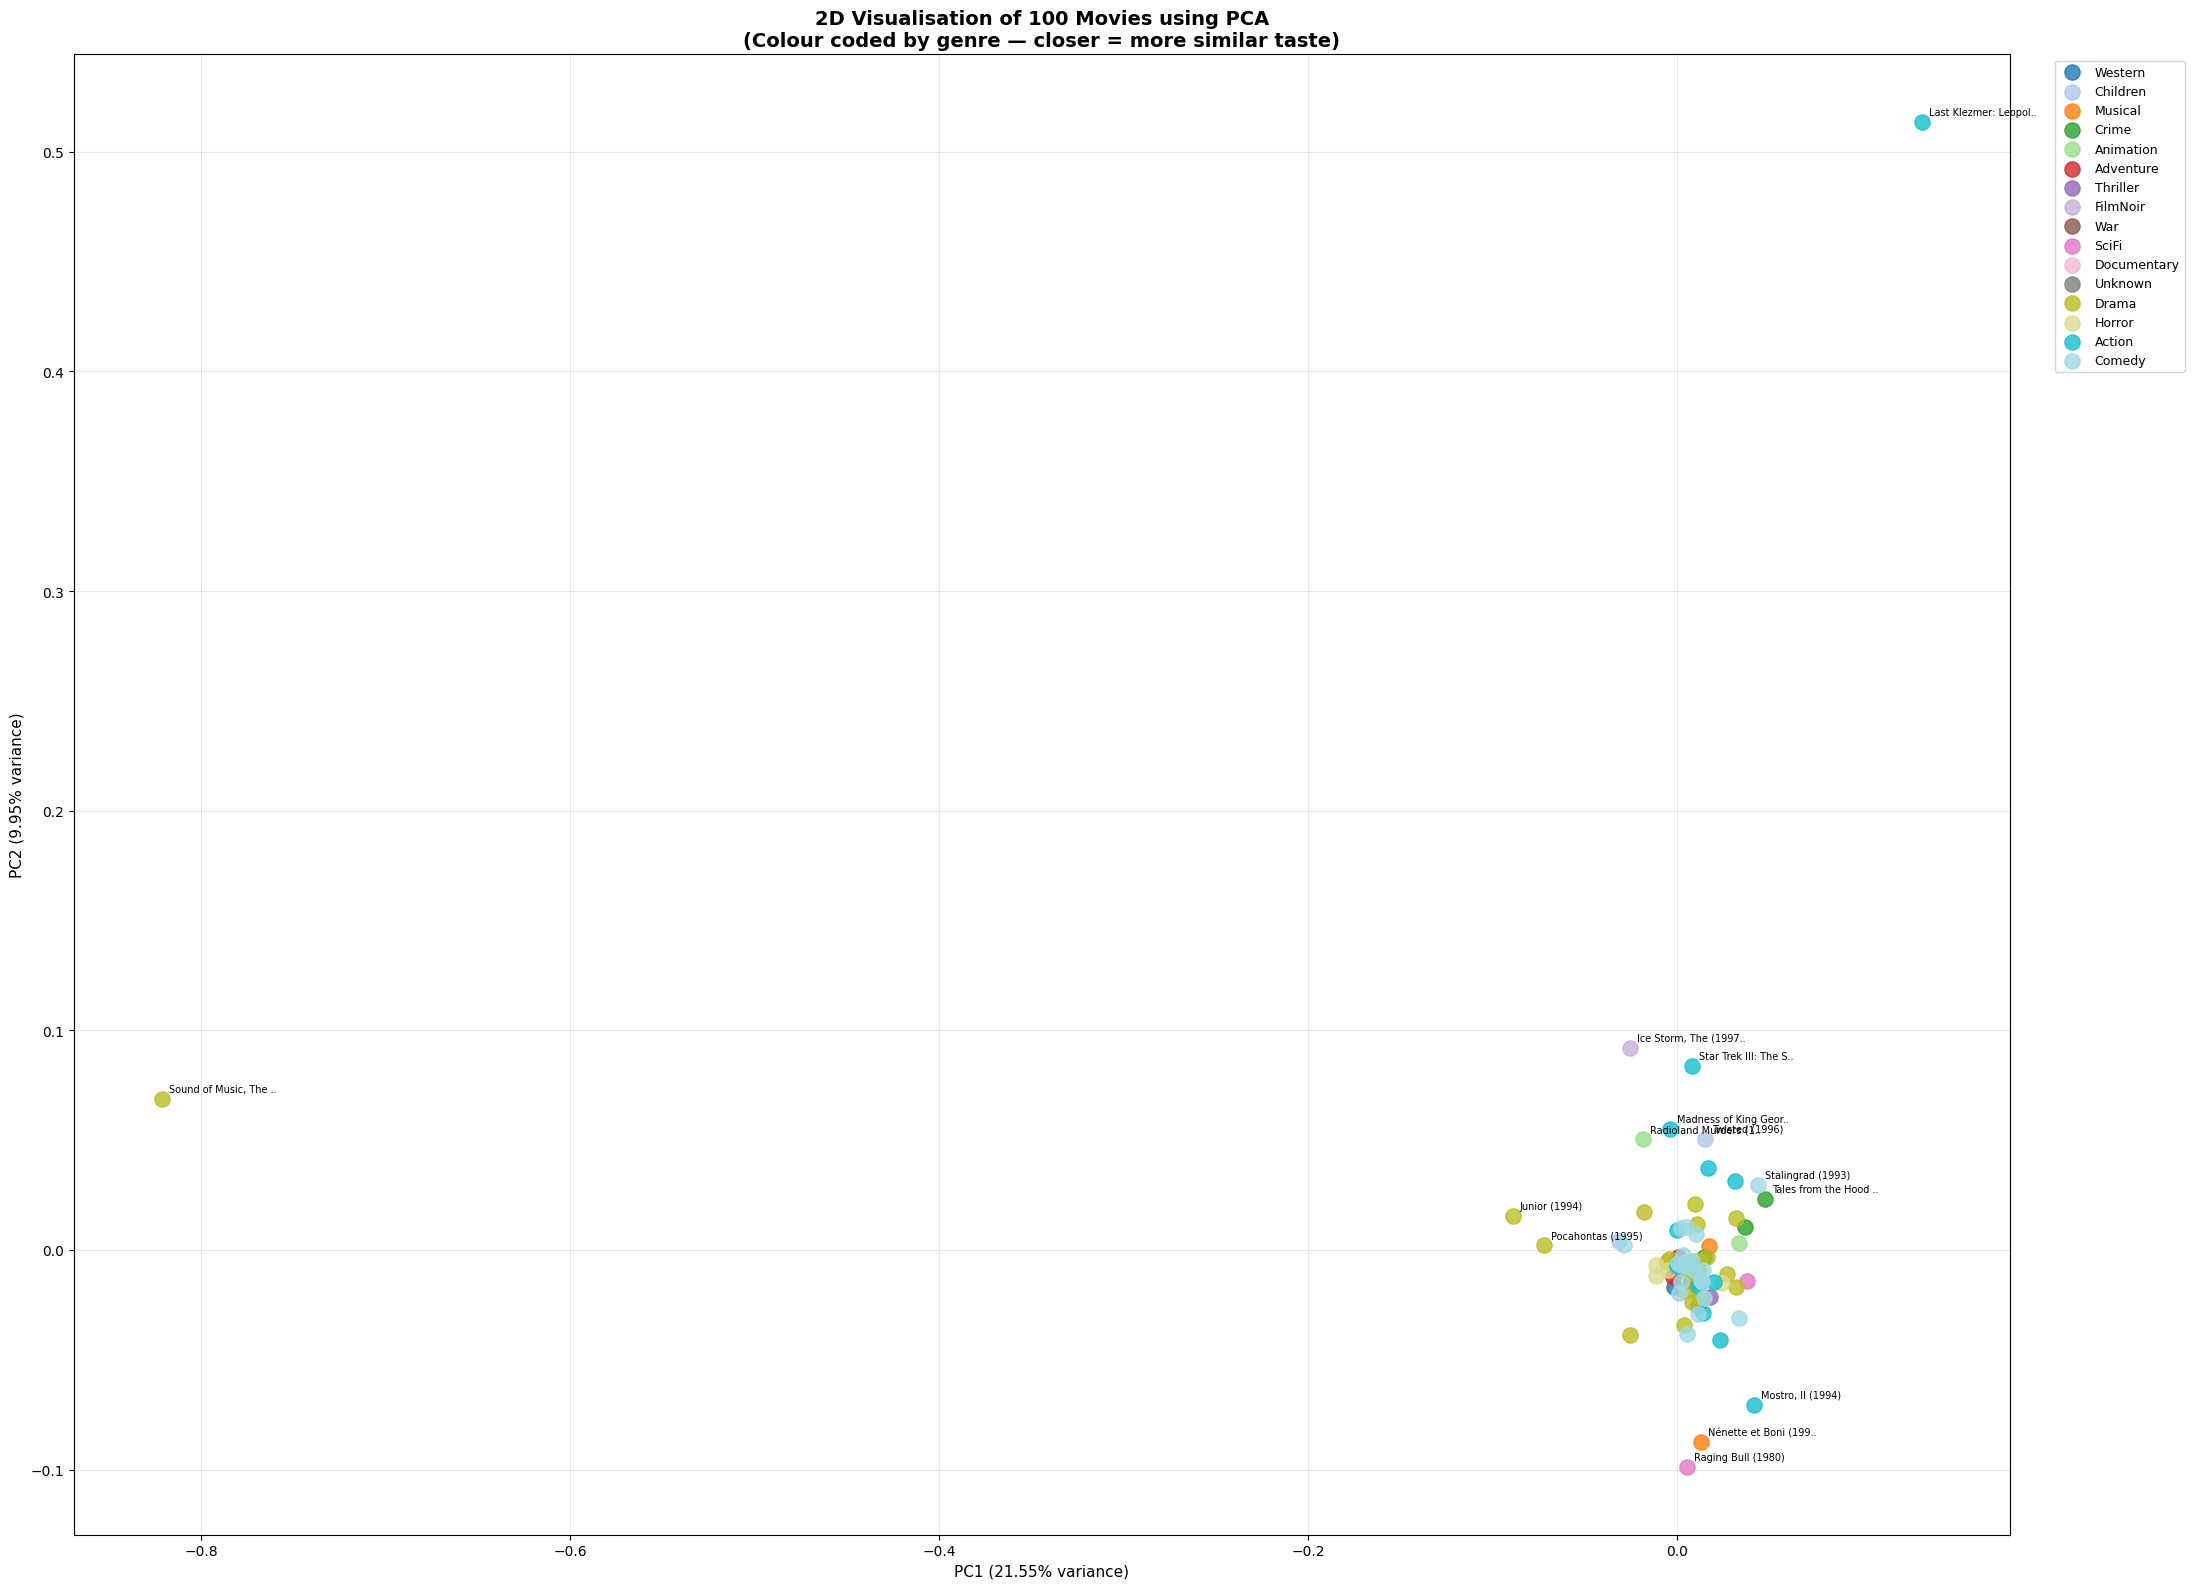

Coloured plot saved!


In [22]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# --- Colour map for genres ---
unique_genres = list(set(sampled_genres))
colors = cm.tab20(np.linspace(0, 1, len(unique_genres)))
genre_color_map = dict(zip(unique_genres, colors))

# --- Plot with better spacing ---
fig, ax = plt.subplots(figsize=(22, 16))

# Plot each genre separately for legend
for genre in unique_genres:
    indices = [i for i, g in enumerate(sampled_genres) if g == genre]
    ax.scatter(movie_2d[indices, 0], movie_2d[indices, 1],
               label=genre,
               alpha=0.8,
               s=120,
               color=genre_color_map[genre])

# Add labels only for outlier movies (far from centre)
centre_x = np.mean(movie_2d[:, 0])
centre_y = np.mean(movie_2d[:, 1])

for i, title in enumerate(sample_titles):
    dist = np.sqrt((movie_2d[i,0]-centre_x)**2 + (movie_2d[i,1]-centre_y)**2)
    short_title = title[:20] + '..' if len(title) > 20 else title
    # Only label movies that are reasonably spread out
    if dist > 0.05:
        ax.annotate(short_title,
                    (movie_2d[i, 0], movie_2d[i, 1]),
                    fontsize=7,
                    xytext=(5, 5),
                    textcoords='offset points')

ax.set_title('2D Visualisation of 100 Movies using PCA\n(Colour coded by genre — closer = more similar taste)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('movie_visualisation_pca_coloured.png', dpi=150, bbox_inches='tight')
plt.show()
print("Coloured plot saved!")

Movies after removing outliers: 98 / 100
Removed: ['Sound of Music, The (1965)', 'Last Klezmer: Leopold Kozlowski, His Life and Music, The (1995)']


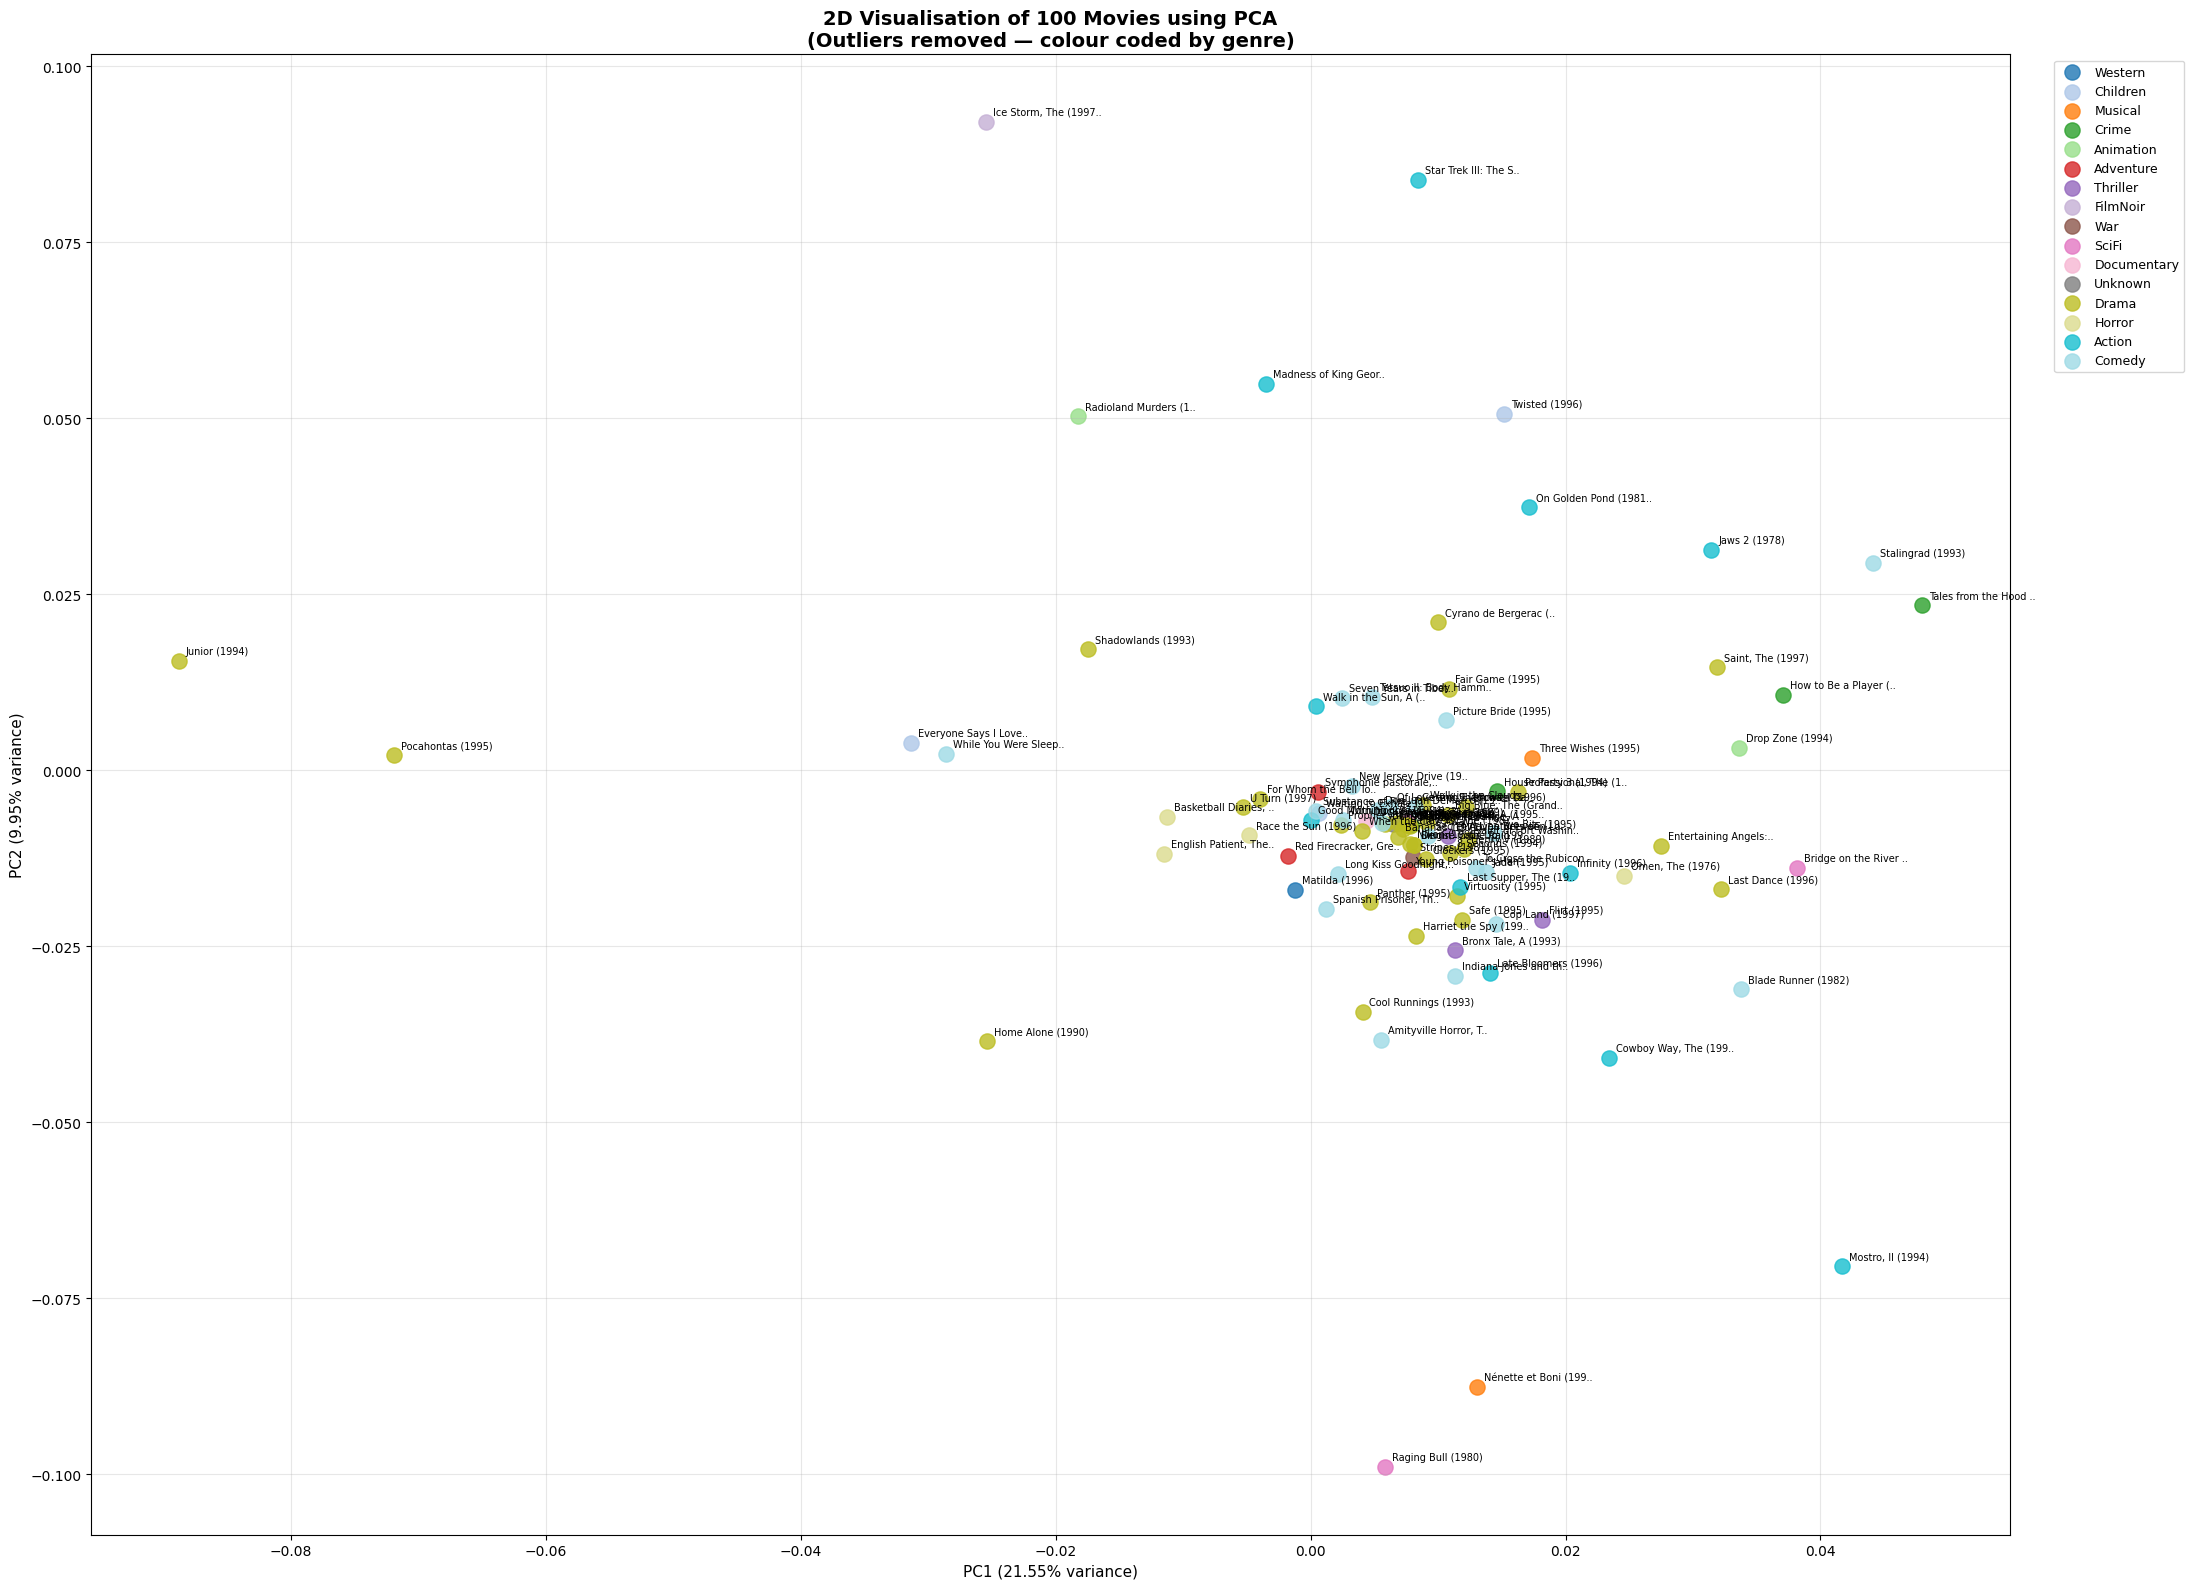

Clean plot saved!


In [23]:
# --- Identify and remove outliers for better visualisation ---
from scipy import stats

# Calculate z-scores to find outliers
z_scores = np.abs(stats.zscore(movie_2d))
outlier_mask = (z_scores < 2.5).all(axis=1)  # keep only non-outliers

# Filter everything
movie_2d_clean = movie_2d[outlier_mask]
sample_titles_clean = sample_titles[outlier_mask]
sampled_genres_clean = [g for g, keep in zip(sampled_genres, outlier_mask) if keep]

print(f"Movies after removing outliers: {outlier_mask.sum()} / 100")
print(f"Removed: {[sample_titles[i] for i, keep in enumerate(outlier_mask) if not keep]}")

# --- Replot without outliers ---
fig, ax = plt.subplots(figsize=(22, 16))

for genre in unique_genres:
    indices = [i for i, g in enumerate(sampled_genres_clean) if g == genre]
    if indices:
        ax.scatter(movie_2d_clean[indices, 0], movie_2d_clean[indices, 1],
                   label=genre, alpha=0.8, s=120,
                   color=genre_color_map[genre])

# Label all movies now that they're spread out
for i, title in enumerate(sample_titles_clean):
    short_title = title[:20] + '..' if len(title) > 20 else title
    ax.annotate(short_title,
                (movie_2d_clean[i, 0], movie_2d_clean[i, 1]),
                fontsize=7,
                xytext=(5, 5),
                textcoords='offset points')

ax.set_title('2D Visualisation of 100 Movies using PCA\n(Outliers removed — colour coded by genre)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('movie_visualisation_pca_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Clean plot saved!")

MDS

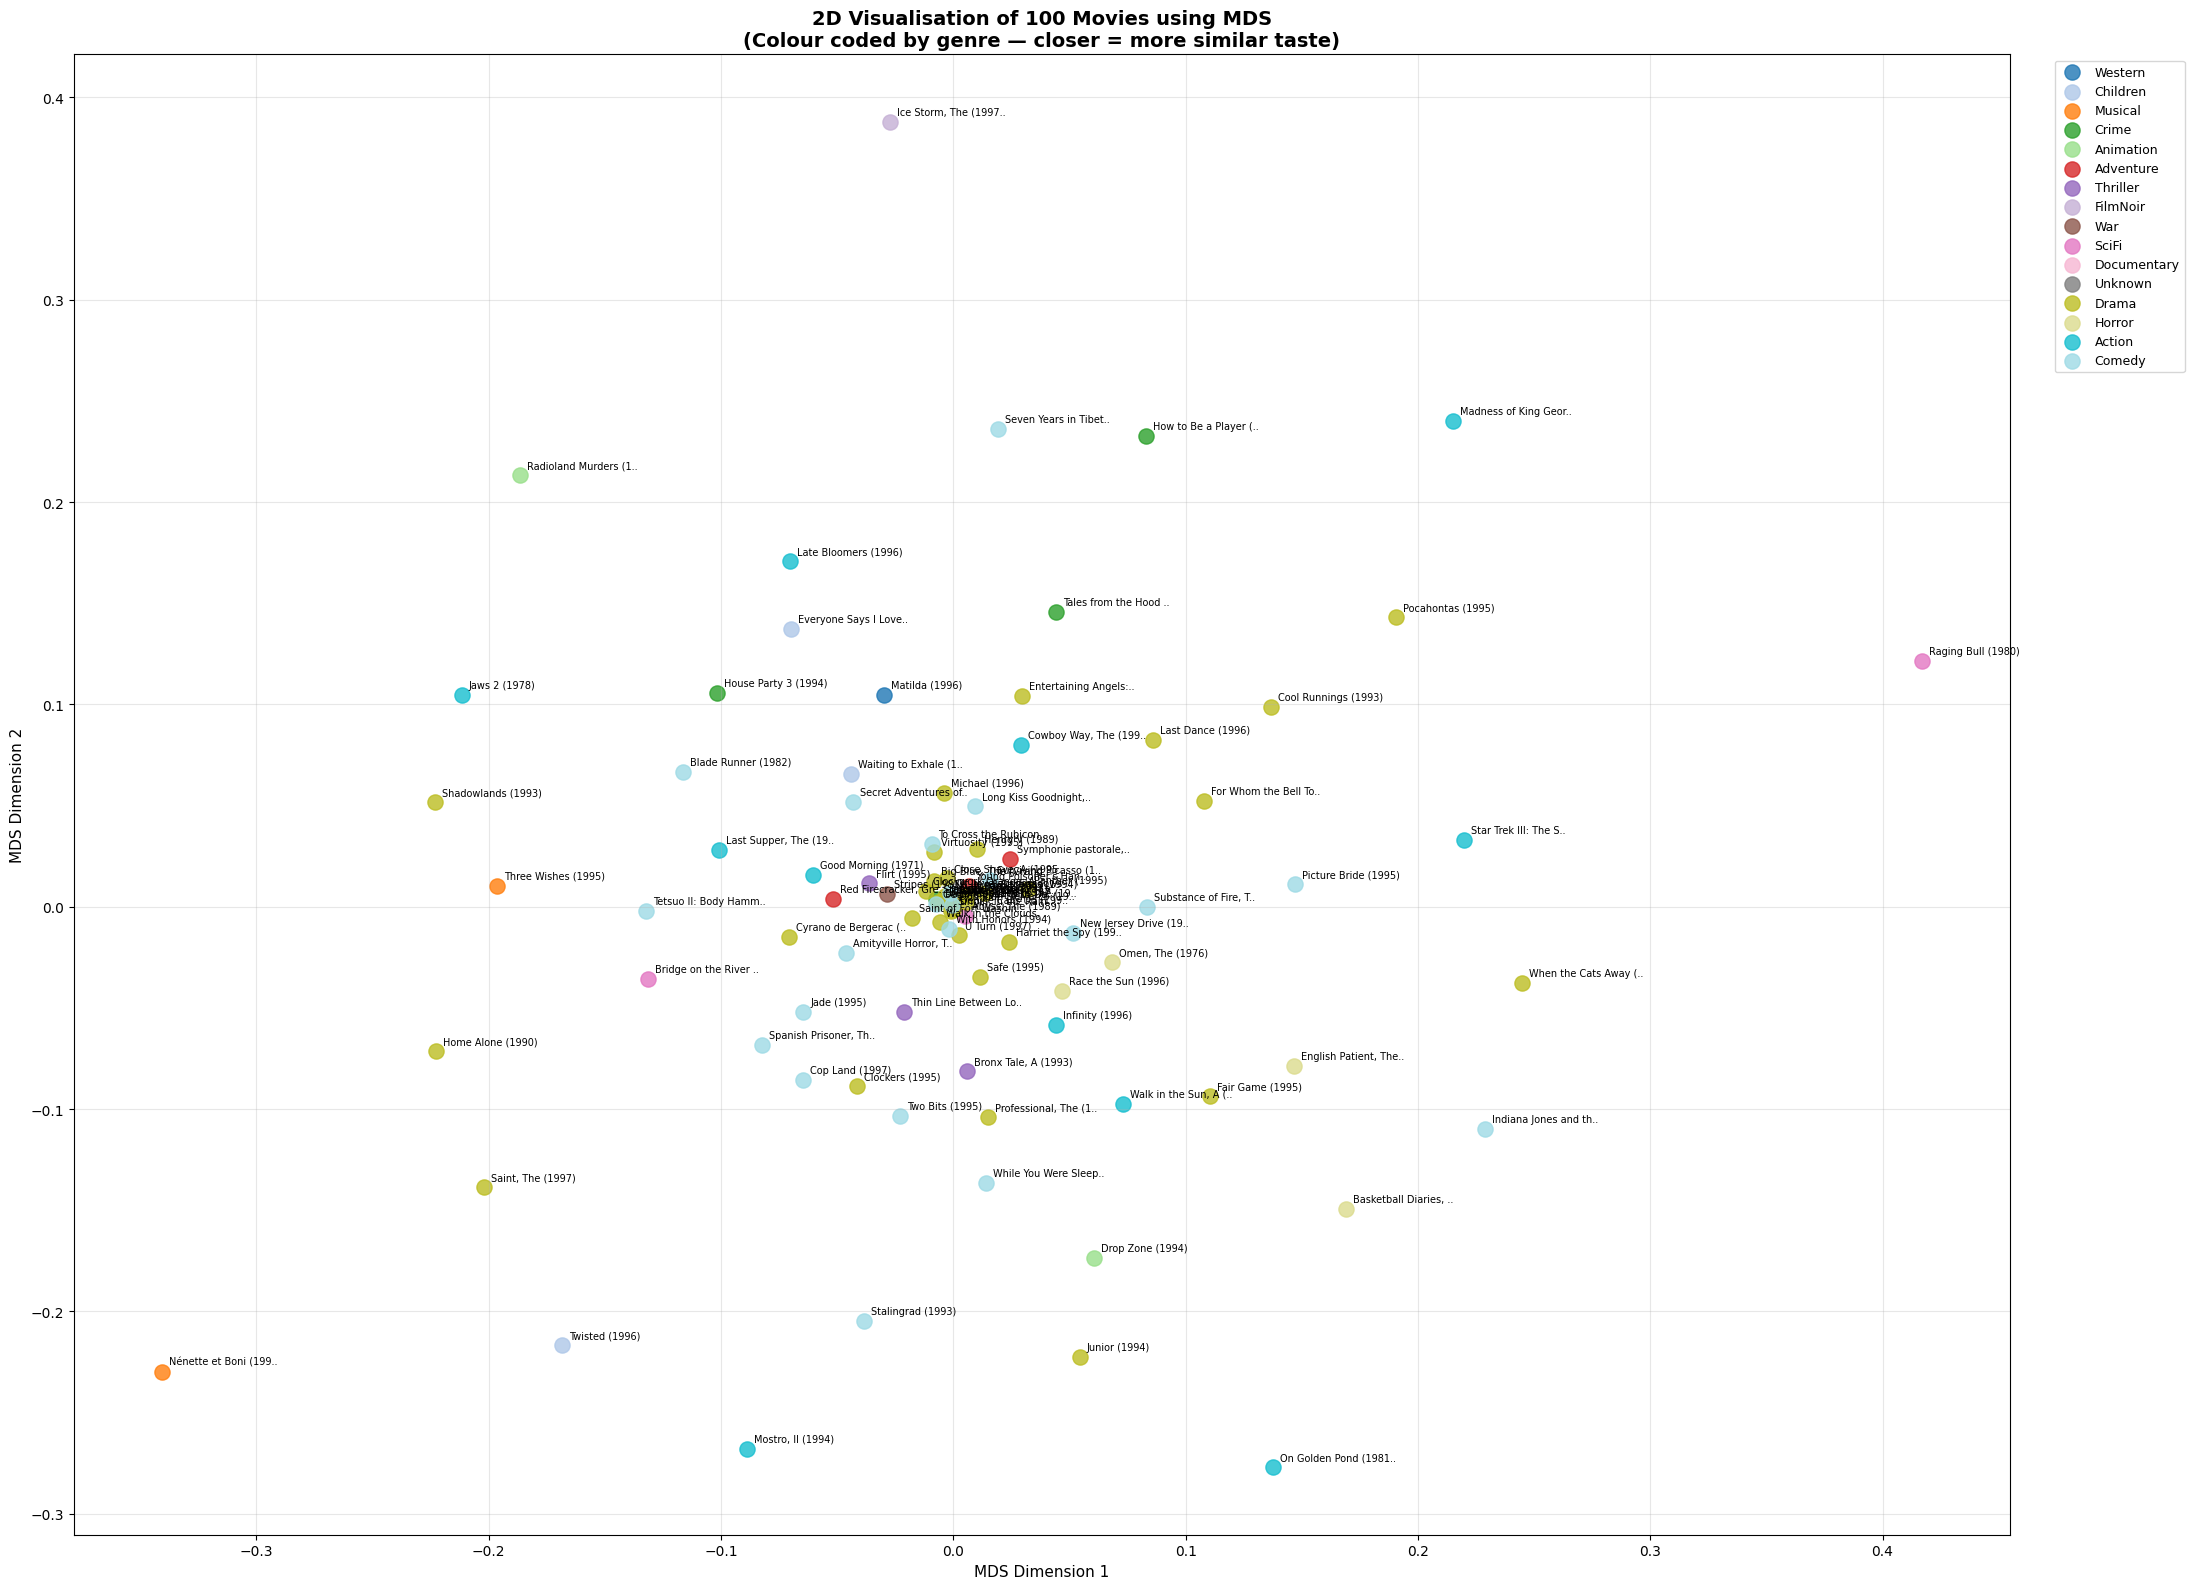

MDS plot saved!


In [24]:
from sklearn.manifold import MDS

# Apply MDS on same sample
mds = MDS(n_components=2, random_state=42, normalized_stress='auto')
movie_2d_mds = mds.fit_transform(sample_factors[outlier_mask])

# Plot MDS
fig, ax = plt.subplots(figsize=(22, 16))

for genre in unique_genres:
    indices = [i for i, g in enumerate(sampled_genres_clean) if g == genre]
    if indices:
        ax.scatter(movie_2d_mds[indices, 0], movie_2d_mds[indices, 1],
                   label=genre, alpha=0.8, s=120,
                   color=genre_color_map[genre])

for i, title in enumerate(sample_titles_clean):
    short_title = title[:20] + '..' if len(title) > 20 else title
    ax.annotate(short_title,
                (movie_2d_mds[i, 0], movie_2d_mds[i, 1]),
                fontsize=7,
                xytext=(5, 5),
                textcoords='offset points')

ax.set_title('2D Visualisation of 100 Movies using MDS\n(Colour coded by genre — closer = more similar taste)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('MDS Dimension 1', fontsize=11)
ax.set_ylabel('MDS Dimension 2', fontsize=11)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('movie_visualisation_mds.png', dpi=150, bbox_inches='tight')
plt.show()
print("MDS plot saved!")

In [25]:
def recommend_movies(user_id, n_recommendations=10):
    # Get this user's predicted ratings
    user_predictions = train_preds_df.loc[user_id].copy()

    # Get movies this user has ALREADY rated (don't recommend these)
    already_rated = train_data[train_data['user_id'] == user_id]['movie_id'].values

    # Remove already rated movies
    user_predictions = user_predictions.drop(already_rated, errors='ignore')

    # Sort by predicted rating (highest first)
    top_movies = user_predictions.nlargest(n_recommendations)

    # Get movie titles
    recommendations = movies[movies['movie_id'].isin(top_movies.index)].copy()
    recommendations['predicted_rating'] = top_movies.values

    return recommendations[['title', 'predicted_rating']].reset_index(drop=True)

# Example: recommend movies for User 1
print("Top 10 movie recommendations for User 1:")
print(recommend_movies(user_id=1))

Top 10 movie recommendations for User 1:
                                               title  predicted_rating
0                                     Platoon (1986)          4.671900
1                          Back to the Future (1985)          4.597734
2                             Raising Arizona (1987)          4.596204
3                       Sense and Sensibility (1995)          4.510140
4                              Secrets & Lies (1996)          4.502982
5                        Nutty Professor, The (1996)          4.474914
6                                 Bob Roberts (1992)          4.416327
7  Dr. Strangelove or: How I Learned to Stop Worr...          4.344801
8                          Lawrence of Arabia (1962)          4.321585
9                                Broken Arrow (1996)          4.316961


In [26]:
def recommend_movies(user_id, n_recommendations=10):
    # Get this user's predicted ratings
    user_predictions = train_preds_df.loc[user_id].copy()

    # Get movies this user has ALREADY rated (don't recommend these)
    already_rated = train_data[train_data['user_id'] == user_id]['movie_id'].values

    # Remove already rated movies
    user_predictions = user_predictions.drop(already_rated, errors='ignore')

    # Sort by predicted rating (highest first)
    top_movies = user_predictions.nlargest(n_recommendations)

    # Get movie titles
    recommendations = movies[movies['movie_id'].isin(top_movies.index)].copy()
    recommendations['predicted_rating'] = top_movies.values

    return recommendations[['title', 'predicted_rating']].reset_index(drop=True)

# --- Show recommendations for 3 different users ---
for user_id in [1, 50, 200]:
    print(f"\nTop 10 recommendations for User {user_id}:")
    print(f"{'Title':<45} {'Predicted Rating':>16}")
    print("-" * 63)
    recs = recommend_movies(user_id=user_id)
    for _, row in recs.iterrows():
        print(f"{row['title']:<45} {row['predicted_rating']:>16.2f}")


Top 10 recommendations for User 1:
Title                                         Predicted Rating
---------------------------------------------------------------
Platoon (1986)                                            4.67
Back to the Future (1985)                                 4.60
Raising Arizona (1987)                                    4.60
Sense and Sensibility (1995)                              4.51
Secrets & Lies (1996)                                     4.50
Nutty Professor, The (1996)                               4.47
Bob Roberts (1992)                                        4.42
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)             4.34
Lawrence of Arabia (1962)                                 4.32
Broken Arrow (1996)                                       4.32

Top 10 recommendations for User 50:
Title                                         Predicted Rating
---------------------------------------------------------------
Twelve Monkey

In [28]:
# Show what each user actually rated highly (for comparison)
for user_id in [1, 50, 200]:
    print(f"\n Movies User {user_id} actually rated highly:")
    print(f"{'Title':<45} {'Actual Rating':>13}")
    print("-" * 60)

    user_actual = train_data[
        (train_data['user_id'] == user_id) &
        (train_data['rating'] >= 4)
    ].merge(movies, on='movie_id')[['title', 'rating']]

    user_actual = user_actual.sort_values('rating', ascending=False).head(5)

    for _, row in user_actual.iterrows():
        print(f"{row['title']:<45} {row['rating']:>13}")


 Movies User 1 actually rated highly:
Title                                         Actual Rating
------------------------------------------------------------
Monty Python and the Holy Grail (1974)                    5
When Harry Met Sally... (1989)                            5
Dolores Claiborne (1994)                                  5
Full Monty, The (1997)                                    5
Aliens (1986)                                             5

 Movies User 50 actually rated highly:
Title                                         Actual Rating
------------------------------------------------------------
Basquiat (1996)                                           5
Pillow Book, The (1995)                                   5
I Shot Andy Warhol (1996)                                 5
Anne Frank Remembered (1995)                              5
Trainspotting (1996)                                      5

 Movies User 200 actually rated highly:
Title                                 

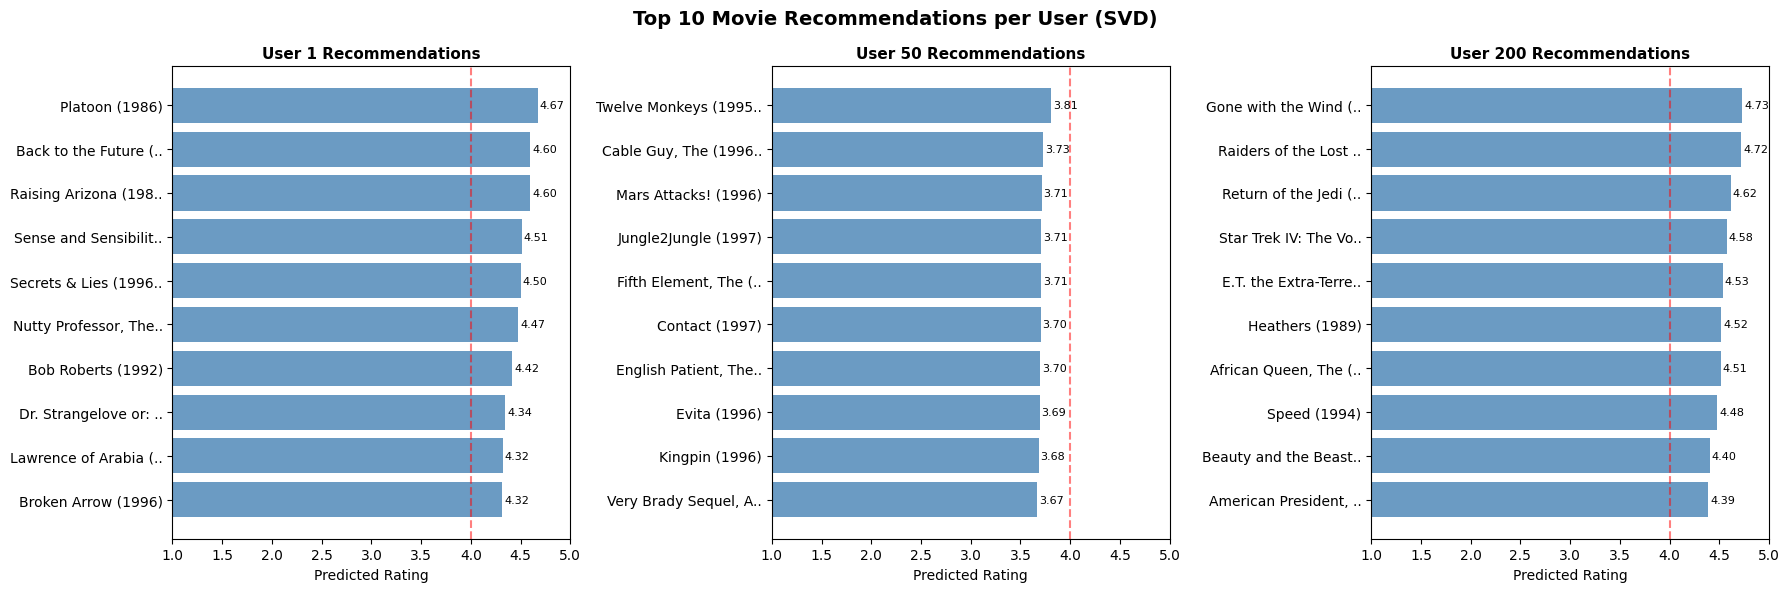

Recommendations plot saved!


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

users = [1, 50, 200]
titles_dict = {}
ratings_dict = {}

for idx, user_id in enumerate(users):
    recs = recommend_movies(user_id=user_id)
    # Shorten titles
    short_titles = [t[:20] + '..' if len(t) > 20 else t
                   for t in recs['title']]
    pred_ratings = recs['predicted_rating'].values

    # Plot horizontal bar chart
    bars = axes[idx].barh(short_titles[::-1],
                          pred_ratings[::-1],
                          color='steelblue',
                          alpha=0.8)

    axes[idx].set_title(f'User {user_id} Recommendations',
                        fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Predicted Rating')
    axes[idx].set_xlim(1, 5)
    axes[idx].axvline(x=4.0, color='red',
                      linestyle='--', alpha=0.5,
                      label='Rating = 4.0')

    # Add value labels
    for bar, rating in zip(bars, pred_ratings[::-1]):
        axes[idx].text(rating + 0.02, bar.get_y() + bar.get_height()/2,
                      f'{rating:.2f}',
                      va='center', fontsize=8)

plt.suptitle('Top 10 Movie Recommendations per User (SVD)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('recommendations_per_user.png', dpi=150, bbox_inches='tight')
plt.show()
print("Recommendations plot saved!")